<a href="https://colab.research.google.com/github/data4class/Teaching/blob/main/Credit_scoring_and_explainability_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Boosting for Credit Scoring

Gradient boosting is an ensemble machine learning technique that builds models sequentially, where each new model corrects errors made by previous models.

**Why Boosting?**
1. Sequential Error Correction: Each tree learns from the mistakes of previous trees

2. Handling Non-linear Relationships: Captures complex patterns in financial data

3. Feature Interactions: Automatically discovers relationships between variables

4. Imbalanced Data: Performs well with typical credit datasets (more good customers than defaults)

**Advantages for Credit Scoring**

1. High Predictive Accuracy: Typically 5-15% improvement over logistic regression

2. Robust to Outliers: Tree-based splits handle extreme values well

3. Mixed Data Types: Handles numerical and categorical features naturally

4. Feature Importance: Provides clear ranking of variable importance

5. Regularization: Built-in techniques prevent overfitting

**Resources:**
1. Boosting: https://www.geeksforgeeks.org/machine-learning/ml-gradient-boosting/

2. SHAP Analysis: https://www.geeksforgeeks.org/machine-learning/shap-a-comprehensive-guide-to-shapley-additive-explanations/

3. Data set: https://www.kaggle.com/datasets/uciml/german-credit

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
from lightgbm import LGBMClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [12]:
# Load the German Credit Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
column_names = [
    'checking_account', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings_account', 'employment', 'installment_rate', 'personal_status',
    'other_parties', 'residence_since', 'property', 'age', 'other_payment_plans',
    'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone',
    'foreign_worker', 'default'
]

df = pd.read_csv(url, sep=' ', header=None, names=column_names)

# Convert target variable (1=good, 2=bad) to (0=good, 1=bad)
df['default'] = df['default'].map({1: 0, 2: 1})

print("Dataset Shape:", df.shape)
print("\nTarget Distribution:")
print(df['default'].value_counts())
print(f"\nDefault Rate: {df['default'].mean():.2%}")

Dataset Shape: (1000, 21)

Target Distribution:
default
0    700
1    300
Name: count, dtype: int64

Default Rate: 30.00%


In [13]:
def preprocess_credit_data(df):
    """
    Preprocess the German Credit Dataset for machine learning
    """
    df_processed = df.copy()

    # Create new features
    df_processed['credit_to_age_ratio'] = df_processed['credit_amount'] / df_processed['age']
    df_processed['duration_to_amount_ratio'] = df_processed['duration'] / df_processed['credit_amount']

    # Encode categorical variables
    categorical_cols = [
        'checking_account', 'credit_history', 'purpose', 'savings_account',
        'employment', 'personal_status', 'other_parties', 'property',
        'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker'
    ]

    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col])
        label_encoders[col] = le

    return df_processed, label_encoders

# Preprocess the data
df_processed, encoders = preprocess_credit_data(df)

# Split features and target
X = df_processed.drop('default', axis=1)
y = df_processed['default']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (800, 22)
Test set shape: (200, 22)


**XGBoost**

In [14]:
def train_xgboost_model(X_train, y_train, X_test, y_test):
    """
    Train and evaluate XGBoost model for credit scoring
    """
    # Define parameters
    xgb_params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': 6,
        'learning_rate': 0.1,
        'n_estimators': 100,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42
    }

    # Train model
    xgb_model = xgb.XGBClassifier(**xgb_params)
    xgb_model.fit(X_train, y_train)

    # Predictions
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
    y_pred = xgb_model.predict(X_test)

    # Evaluate
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"XGBoost AUC Score: {auc_score:.4f}")

    return xgb_model, y_pred_proba, y_pred

xgb_model, xgb_proba, xgb_pred = train_xgboost_model(X_train, y_train, X_test, y_test)

XGBoost AUC Score: 0.7863


**Light Gradient Boosting Model**

In [15]:
def train_lightgbm_model(X_train, y_train, X_test, y_test):
    """
    Train and evaluate LightGBM model for credit scoring
    """
    # Define parameters
    lgb_params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'num_leaves': 31,
        'learning_rate': 0.1,
        'n_estimators': 100,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'random_state': 42,
        'verbose': -1
    }

    # Train model
    lgb_model = LGBMClassifier(**lgb_params)
    lgb_model.fit(X_train, y_train)

    # Predictions
    y_pred_proba = lgb_model.predict_proba(X_test)[:, 1]
    y_pred = lgb_model.predict(X_test)

    # Evaluate
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"LightGBM AUC Score: {auc_score:.4f}")

    return lgb_model, y_pred_proba, y_pred

lgb_model, lgb_proba, lgb_pred = train_lightgbm_model(X_train, y_train, X_test, y_test)

LightGBM AUC Score: 0.7856


**Hyper perameter optimization**

In [17]:
def optimize_lightgbm_hyperparameters(X_train, y_train):
    """
    Optimize LightGBM hyperparameters using GridSearchCV
    """
    param_grid = {
        'num_leaves': [15, 31, 63],
        'learning_rate': [0.05, 0.1, 0.2],
        'n_estimators': [50, 100, 200],
        'min_child_samples': [10, 20, 30],
        'subsample': [0.8, 0.9, 1.0]
    }

    lgb_model = LGBMClassifier(
        objective='binary',
        metric='auc',
        random_state=42,
        verbose=-1
    )

    grid_search = GridSearchCV(
        lgb_model,
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    print("Best parameters:", grid_search.best_params_)
    print("Best CV AUC score:", grid_search.best_score_)

    return grid_search.best_estimator_

# Optimize hyperparameters (commented out for faster execution)
best_lgb_model = optimize_lightgbm_hyperparameters(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters: {'learning_rate': 0.1, 'min_child_samples': 30, 'n_estimators': 50, 'num_leaves': 15, 'subsample': 0.8}
Best CV AUC score: 0.779985119047619


**Evaluation and visualization**


LightGBM Performance:
AUC Score: 0.7856

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       140
           1       0.65      0.55      0.59        60

    accuracy                           0.78       200
   macro avg       0.73      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200



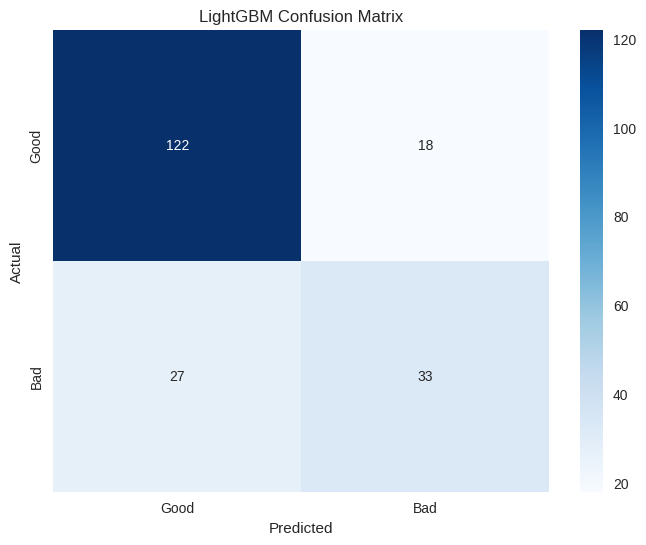

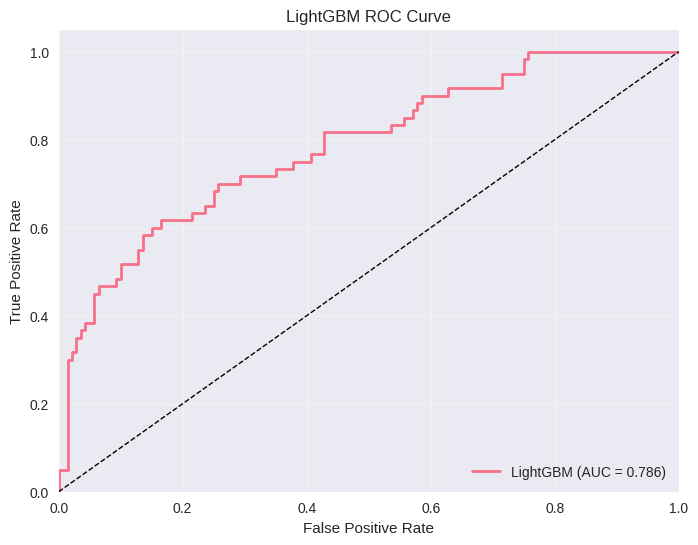

In [18]:
def evaluate_model_performance(y_true, y_pred, y_pred_proba, model_name="Model"):
    """
    Comprehensive model evaluation for credit scoring
    """
    # AUC Score
    auc = roc_auc_score(y_true, y_pred_proba)

    # Classification Report
    print(f"\n{model_name} Performance:")
    print("=" * 50)
    print(f"AUC Score: {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

# Evaluate LightGBM model
evaluate_model_performance(y_test, lgb_pred, lgb_proba, "LightGBM")

**Feature Importance Analysis**

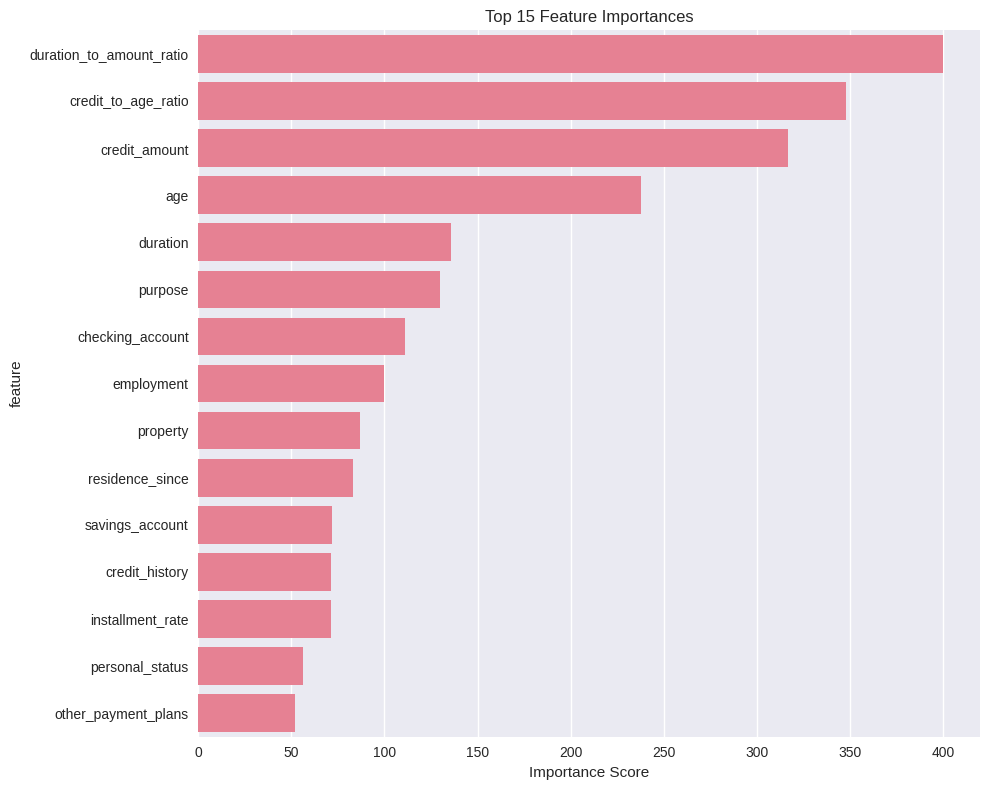


Top 10 Most Important Features:
                     feature  importance
21  duration_to_amount_ratio         400
20       credit_to_age_ratio         348
4              credit_amount         317
12                       age         238
1                   duration         136
3                    purpose         130
0           checking_account         111
6                 employment         100
11                  property          87
10           residence_since          83


In [8]:
def plot_feature_importance(model, feature_names, top_n=15):
    """
    Plot feature importance for gradient boosting model
    """
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        importances = model.booster_.feature_importance(importance_type='gain')

    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(top_n)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_importance, y='feature', x='importance')
    plt.title(f'Top {top_n} Feature Importances')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    return feature_importance

# Plot feature importance
feature_importance = plot_feature_importance(lgb_model, X.columns)
print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

**SHAP Analysis for Model Interpretability**

In [36]:
def shap_analysis(model, X_test, sample_size=100):
    """
    Perform SHAP analysis for model interpretability
    """
    # Create SHAP TreeExplainer using the model's booster object
    explainer = shap.TreeExplainer(model.booster_)

    # Calculate SHAP values for a sample of test data
    X_sample = X_test.sample(n=min(sample_size, len(X_test)), random_state=42)
    shap_values = explainer.shap_values(X_sample)

    # Summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values[1], X_sample, plot_type="bar", show=False) # Use index 1 for the positive class
    plt.title("SHAP Feature Importance")
    plt.tight_layout()
    plt.show()

    # Detailed summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values[1], X_sample, show=False) # Use index 1 for the positive class
    plt.title("SHAP Summary Plot")
    plt.tight_layout()
    plt.show()

    return explainer, shap_values

# Perform SHAP analysis
explainer, shap_values = shap_analysis(lgb_model, X_test)

AssertionError: Summary plots need a matrix of shap_values, not a vector.

<Figure size 1000x800 with 0 Axes>

In [22]:
help(shap)

Help on package shap:

NAME
    shap

PACKAGE CONTENTS
    _cext
    _explanation
    _serializable
    _version
    actions (package)
    benchmark (package)
    datasets
    explainers (package)
    links
    maskers (package)
    models (package)
    plots (package)
    utils (package)

SUBMODULES
    other

CLASSES
    builtins.object
        shap._explanation.Cohorts
        shap._explanation.Explanation
        shap.actions._optimizer.ActionOptimizer
    shap._serializable.Serializable(builtins.object)
        shap.explainers._explainer.Explainer
            shap.explainers._additive.AdditiveExplainer
            shap.explainers._coalition.CoalitionExplainer
            shap.explainers._deep.DeepExplainer
            shap.explainers._exact.ExactExplainer
            shap.explainers._gradient.GradientExplainer
            shap.explainers._kernel.KernelExplainer
                shap.explainers._sampling.SamplingExplainer
            shap.explainers._linear.LinearExplainer
         

**Model compare**

Model Comparison:
   Model  AUC Score
 XGBoost   0.786310
LightGBM   0.785595


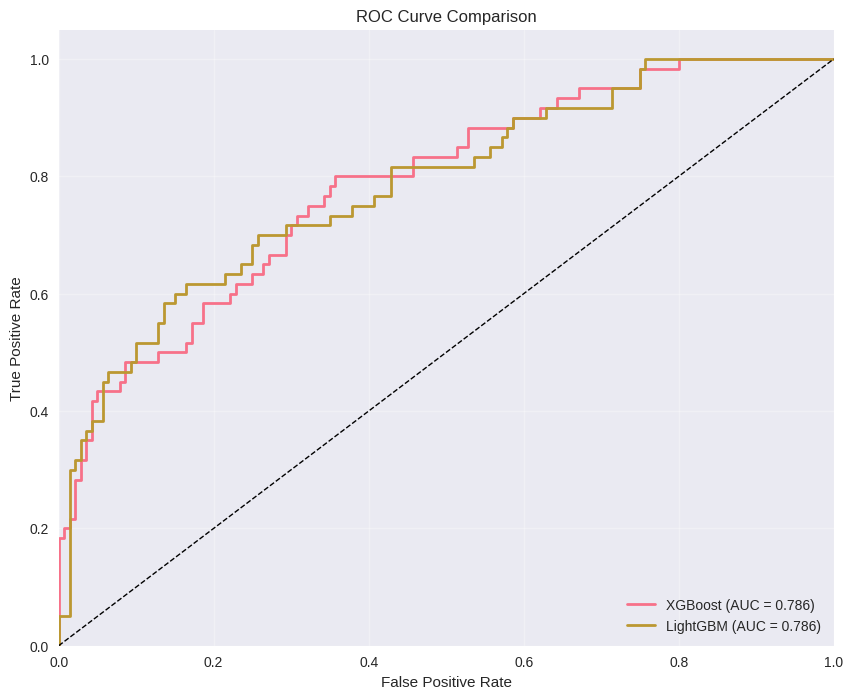

In [21]:
def compare_models(models_dict, X_test, y_test):
    """
    Compare multiple gradient boosting models
    """
    results = {}

    for name, (model, proba, pred) in models_dict.items():
        auc = roc_auc_score(y_test, proba)
        results[name] = {
            'AUC': auc,
            'Model': model,
            'Predictions': proba
        }

    # Create comparison DataFrame
    comparison_df = pd.DataFrame({
        'Model': list(results.keys()),
        'AUC Score': [results[model]['AUC'] for model in results.keys()]
    }).sort_values('AUC Score', ascending=False)

    print("Model Comparison:")
    print("=" * 30)
    print(comparison_df.to_string(index=False))

    # Plot ROC curves for all models
    plt.figure(figsize=(10, 8))
    for name in results.keys():
        fpr, tpr, _ = roc_curve(y_test, results[name]['Predictions'])
        auc = results[name]['AUC']
        plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

    return comparison_df

# Compare models
models_comparison = {
    'XGBoost': (xgb_model, xgb_proba, xgb_pred),
    'LightGBM': (lgb_model, lgb_proba, lgb_pred)
}

comparison_results = compare_models(models_comparison, X_test, y_test)

**Business Decision**